In [6]:
# Imports and dataset setup
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("/content/drive/MyDrive/sample_data")

files = sorted(DATA_DIR.glob("*.csv"))

accelerometer_files = [
    file for file in files
    if "accelerometer" in file.name.lower()
]

gyroscope_files = [
    file for file in files
    if "gyroscope" in file.name.lower()
]

def get_user_id(file):
    return re.match(r"^(\d+)_", file.name).group(1)

acc_by_user = {
    get_user_id(file): file
    for file in accelerometer_files
}

gyro_by_user = {
    get_user_id(file): file
    for file in gyroscope_files
}

print(f"Total CSV files: {len(files)}")
print(f"Accelerometer files: {len(accelerometer_files)}")
print(f"Gyroscope files: {len(gyroscope_files)}")
print(f"Users: {sorted(acc_by_user, key=int)}")

Total CSV files: 20
Accelerometer files: 10
Gyroscope files: 10
Users: ['2', '13', '23', '24', '49', '52', '55', '70', '78', '112']


In [7]:
# Sensor combination function
def combine_user_data(user_id):
    """
    Combine one user's accelerometer and gyroscope data using EID.

    Output columns:
    EID, time, Acc-X, Acc-Y, Acc-Z, Gyro-X, Gyro-Y, Gyro-Z
    """

    acc = pd.read_csv(acc_by_user[user_id])
    gyro = pd.read_csv(gyro_by_user[user_id])

    # Convert timestamps from strings to datetime objects
    acc["time"] = pd.to_datetime(acc["time"])
    gyro["time"] = pd.to_datetime(gyro["time"])

    # Rename sensor-specific columns
    acc = acc.rename(columns={
        "Xvalue": "Acc-X",
        "Yvalue": "Acc-Y",
        "Zvalue": "Acc-Z",
        "time": "time_acc"
    })

    gyro = gyro.rename(columns={
        "Xvalue": "Gyro-X",
        "Yvalue": "Gyro-Y",
        "Zvalue": "Gyro-Z",
        "time": "time_gyro"
    })

    # Align the two sensors using EID
    combined = pd.merge(
        acc[["EID", "time_acc", "Acc-X", "Acc-Y", "Acc-Z"]],
        gyro[["EID", "time_gyro", "Gyro-X", "Gyro-Y", "Gyro-Z"]],
        on="EID",
        how="inner",
        validate="one_to_one"
    )

    # Use the accelerometer timestamp as the primary timestamp.
    # The timestamps are already nearly identical after EID alignment.
    combined["time"] = combined["time_acc"]

    # Keep only the columns needed from this point onward
    combined = combined[
        [
            "EID",
            "time",
            "Acc-X",
            "Acc-Y",
            "Acc-Z",
            "Gyro-X",
            "Gyro-Y",
            "Gyro-Z"
        ]
    ]

    combined = combined.sort_values("EID").reset_index(drop=True)

    return combined

In [8]:
# Combine accelerometer and gyroscope data for every user

combined_data_by_user = {}

for user_id in sorted(acc_by_user, key=int):
    combined_data_by_user[user_id] = combine_user_data(user_id)

# Create a summary table
summary_rows = []

for user_id, data in combined_data_by_user.items():
    duration_seconds = (
        data["time"].iloc[-1] - data["time"].iloc[0]
    ).total_seconds()

    summary_rows.append({
        "User": user_id,
        "Rows": len(data),
        "Columns": len(data.columns),
        "Duration (seconds)": round(duration_seconds, 2),
        "Missing values": int(data.isna().sum().sum()),
        "Unique EIDs": data["EID"].is_unique,
        "Sorted EIDs": data["EID"].is_monotonic_increasing
    })

combined_summary = pd.DataFrame(summary_rows)

display(combined_summary)

,User,Rows,Columns,Duration (seconds),Missing values,Unique EIDs,Sorted EIDs
0,2,35105,8,2008.39,0,True,True
1,13,30459,8,1859.37,0,True,True
2,23,34105,8,2696.44,0,True,True
3,24,23296,8,2955.28,0,True,True
4,49,25954,8,15627.53,0,True,True
5,52,25029,8,2062.08,0,True,True
6,55,29894,8,3045.54,0,True,True
7,70,28173,8,2160.84,0,True,True
8,78,22199,8,1464.34,0,True,True
9,112,26343,8,2626.25,0,True,True


In [9]:
# Validate and save all combined user datasets

required_columns = [
    "EID",
    "time",
    "Acc-X",
    "Acc-Y",
    "Acc-Z",
    "Gyro-X",
    "Gyro-Y",
    "Gyro-Z"
]

validation_results = []
first_rows = []

for user_id, data in combined_data_by_user.items():

    # Basic structural checks
    correct_columns = list(data.columns) == required_columns
    no_missing_values = data.isna().sum().sum() == 0
    unique_eids = data["EID"].is_unique
    sorted_eids = data["EID"].is_monotonic_increasing
    sorted_time = data["time"].is_monotonic_increasing

    validation_results.append({
        "User": user_id,
        "Rows": len(data),
        "Correct columns": correct_columns,
        "No missing values": no_missing_values,
        "Unique EIDs": unique_eids,
        "Sorted EIDs": sorted_eids,
        "Sorted timestamps": sorted_time
    })

    # Keep the first three rows for visual inspection
    preview = data.head(3).copy()
    preview.insert(0, "User", user_id)
    first_rows.append(preview)

validation_results = pd.DataFrame(validation_results)
preview_table = pd.concat(first_rows, ignore_index=True)

print("Validation results:")
display(validation_results)

print("\nFirst three combined rows for every user:")
display(preview_table)

Validation results:


,User,Rows,Correct columns,No missing values,Unique EIDs,Sorted EIDs,Sorted timestamps
0,2,35105,True,True,True,True,True
1,13,30459,True,True,True,True,True
2,23,34105,True,True,True,True,True
3,24,23296,True,True,True,True,True
4,49,25954,True,True,True,True,True
5,52,25029,True,True,True,True,True
6,55,29894,True,True,True,True,True
7,70,28173,True,True,True,True,True
8,78,22199,True,True,True,True,True
9,112,26343,True,True,True,True,True



First three combined rows for every user:


,User,EID,time,Acc-X,Acc-Y,Acc-Z,Gyro-X,Gyro-Y,Gyro-Z
0,2,0,2017-04-17 14:44:43.026,1.978808,-1.114501,3.514688,0.579504,-0.647681,0.233293
1,2,1,2017-04-17 14:44:43.036,0.810437,-2.832341,2.801216,1.075917,-1.181378,0.243946
2,2,2,2017-04-17 14:44:43.045,-0.252588,-5.337873,2.322376,1.538242,-1.643703,0.274838
3,13,0,2017-04-30 13:43:48.135,1.709460,-8.427590,1.788469,-0.291882,-0.509196,-0.285491
4,13,1,2017-04-30 13:43:48.145,1.841141,-8.421604,2.276886,-0.229032,-0.484695,-0.206661
5,13,2,2017-04-30 13:43:48.156,1.766921,-8.445546,2.078167,-0.147006,-0.353668,-0.145941
6,23,0,2017-05-04 13:43:24.261,-0.156820,10.687716,-0.839168,-0.514523,-0.298274,0.377104
7,23,1,2017-05-04 13:43:24.271,-0.160412,11.465832,0.017957,-0.305731,0.070307,0.540089
8,23,2,2017-05-04 13:43:24.281,-0.076614,12.257115,0.442927,-0.118244,0.434628,0.694552
9,24,0,2017-05-04 16:53:16.366,1.115698,-3.190274,-6.921637,-0.022371,-0.896953,0.639159


In [11]:
from pathlib import Path

COMBINED_DIR = Path(
    "/content/drive/MyDrive/processed_data/combined"
)

COMBINED_DIR.mkdir(parents=True, exist_ok=True)

for user_id, data in combined_data_by_user.items():
    output_path = COMBINED_DIR / f"user_{user_id}_combined.csv"
    data.to_csv(output_path, index=False)

print(f"Saved {len(combined_data_by_user)} combined files to:")
print(COMBINED_DIR)

Saved 10 combined files to:
/content/drive/MyDrive/processed_data/combined


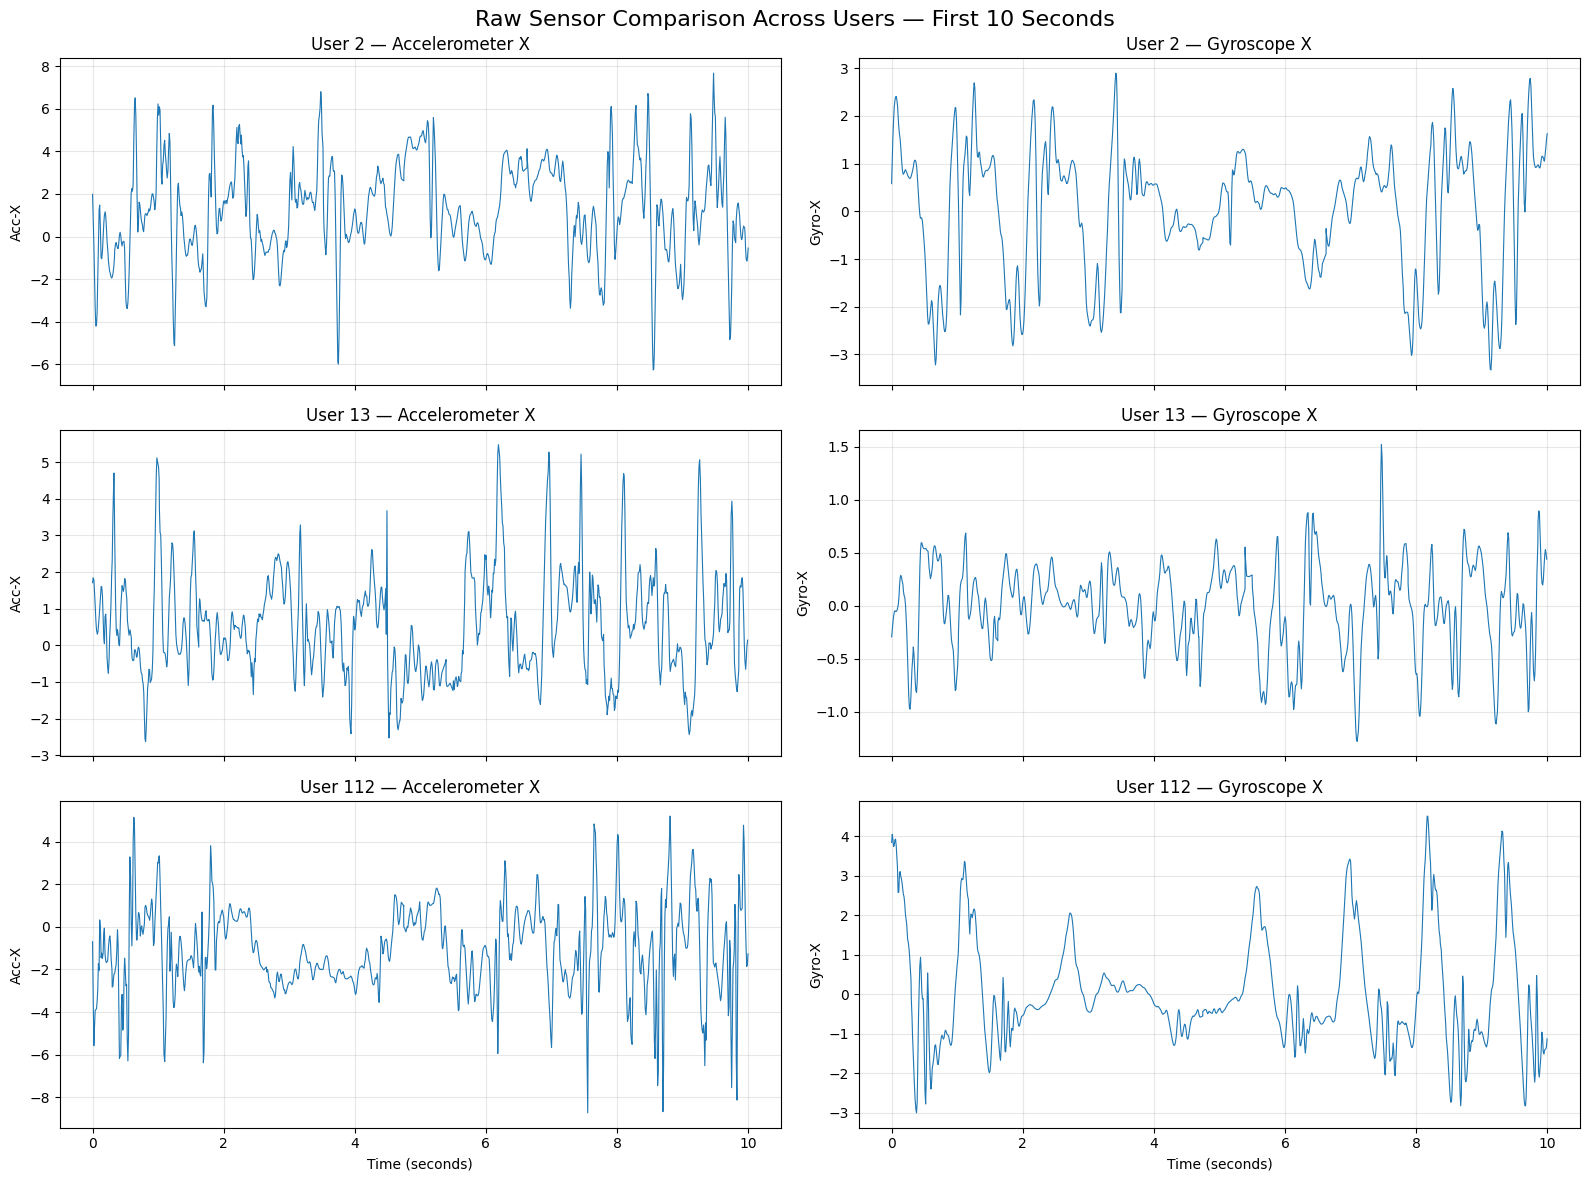

In [12]:
user_ids_to_plot = ["2", "13", "112"]

channels_to_plot = [
    "Acc-X",
    "Acc-Y",
    "Acc-Z",
    "Gyro-X",
    "Gyro-Y",
    "Gyro-Z"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 12),
    sharex=True
)

for row, user_id in enumerate(user_ids_to_plot):
    user_data = combine_user_data(user_id)

    time_seconds = (
        user_data["time"] - user_data["time"].iloc[0]
    ).dt.total_seconds()

    plot_mask = time_seconds <= 10

    # Plot Acc-X
    axes[row, 0].plot(
        time_seconds[plot_mask],
        user_data.loc[plot_mask, "Acc-X"],
        linewidth=0.8
    )

    axes[row, 0].set_title(f"User {user_id} — Accelerometer X")
    axes[row, 0].set_ylabel("Acc-X")
    axes[row, 0].grid(True, alpha=0.3)

    # Plot Gyro-X
    axes[row, 1].plot(
        time_seconds[plot_mask],
        user_data.loc[plot_mask, "Gyro-X"],
        linewidth=0.8
    )

    axes[row, 1].set_title(f"User {user_id} — Gyroscope X")
    axes[row, 1].set_ylabel("Gyro-X")
    axes[row, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Time (seconds)")
axes[-1, 1].set_xlabel("Time (seconds)")

fig.suptitle(
    "Raw Sensor Comparison Across Users — First 10 Seconds",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

SAMPLING_RATE = 100
WINDOW_SIZE = 5 * SAMPLING_RATE   # 500 samples
STRIDE = WINDOW_SIZE // 2         # 250 samples
GAP_THRESHOLD = 0.1               # seconds

segment_summary = []

for user_id, data in combined_data_by_user.items():

    data = data.copy()

    # Calculate time difference between consecutive samples
    time_differences = (
        data["time"].diff().dt.total_seconds().fillna(0)
    )

    # A new segment begins after a large time gap
    data["segment_id"] = (
        time_differences > GAP_THRESHOLD
    ).cumsum()

    for segment_id, segment in data.groupby("segment_id"):
        segment_length = len(segment)

        if segment_length >= WINDOW_SIZE:
            possible_windows = (
                1 + (segment_length - WINDOW_SIZE) // STRIDE
            )
        else:
            possible_windows = 0

        segment_summary.append({
            "User": user_id,
            "Segment": int(segment_id),
            "Samples": segment_length,
            "Duration (seconds)": round(
                (segment["time"].iloc[-1] - segment["time"].iloc[0])
                .total_seconds(),
                2
            ),
            "Possible windows": possible_windows
        })

segment_summary = pd.DataFrame(segment_summary)

print("Continuous-segment summary:")
display(segment_summary)

print("Total possible windows per user:")

windows_per_user = (
    segment_summary
    .groupby("User")["Possible windows"]
    .sum()
    .reset_index(name="Total possible windows")
)

display(windows_per_user)

Continuous-segment summary:


,User,Segment,Samples,Duration (seconds),Possible windows
0,2,0,16121,160.25,63
1,2,1,2466,24.56,8
2,2,2,16518,164.42,65
3,13,0,15691,156.02,61
4,13,1,5094,50.64,19
5,13,2,9674,96.08,37
6,23,0,16965,168.60,66
7,23,1,284,2.80,0
8,23,2,16856,167.27,66
9,24,0,15680,155.95,61


Total possible windows per user:


,User,Total possible windows
0,112,101
1,13,117
2,2,136
3,23,132
4,24,90
5,49,101
6,52,95
7,55,117
8,70,108
9,78,84


In [14]:
# CREATE ALL WINDOWS

import numpy as np

CHANNELS = [
    "Acc-X",
    "Acc-Y",
    "Acc-Z",
    "Gyro-X",
    "Gyro-Y",
    "Gyro-Z"
]

windows_by_user = {}
all_windows = []
all_labels = []
window_metadata = []

for user_id, data in combined_data_by_user.items():

    data = data.copy()

    # Calculate time gaps between consecutive samples
    time_differences = (
        data["time"].diff().dt.total_seconds().fillna(0)
    )

    # Assign a new segment after a large recording gap
    data["segment_id"] = (
        time_differences > GAP_THRESHOLD
    ).cumsum()

    user_windows = []

    for segment_id, segment in data.groupby("segment_id"):

        segment_values = segment[CHANNELS].to_numpy(
            dtype=np.float32
        )

        # Sliding windows with 50% overlap
        for start in range(
            0,
            len(segment_values) - WINDOW_SIZE + 1,
            STRIDE
        ):
            end = start + WINDOW_SIZE

            window = segment_values[start:end]

            user_windows.append(window)
            all_windows.append(window)
            all_labels.append(user_id)

            window_metadata.append({
                "User": user_id,
                "Segment": int(segment_id),
                "Start index": start,
                "End index": end,
                "Start EID": int(segment["EID"].iloc[start]),
                "End EID": int(segment["EID"].iloc[end - 1])
            })

    windows_by_user[user_id] = np.array(
        user_windows,
        dtype=np.float32
    )

# Convert all windows and labels into arrays
X_windows = np.stack(all_windows)
y_users = np.array(all_labels)

window_metadata = pd.DataFrame(window_metadata)

print("Windowing complete")
print("-" * 50)
print(f"X_windows shape: {X_windows.shape}")
print(f"y_users shape:   {y_users.shape}")
print(f"Number of users:  {len(np.unique(y_users))}")

print("\nExpected window shape:")
print("(500 time steps, 6 channels)")

print("\nWindows per user:")
print(
    pd.Series(y_users)
    .value_counts()
    .sort_index()
    .rename_axis("User")
    .reset_index(name="Windows")
)

print("\nWindow metadata preview:")
display(window_metadata.head())

Windowing complete
--------------------------------------------------
X_windows shape: (1081, 500, 6)
y_users shape:   (1081,)
Number of users:  10

Expected window shape:
(500 time steps, 6 channels)

Windows per user:
  User  Windows
0  112      101
1   13      117
2    2      136
3   23      132
4   24       90
5   49      101
6   52       95
7   55      117
8   70      108
9   78       84

Window metadata preview:


,User,Segment,Start index,End index,Start EID,End EID
0,2,0,0,500,0,499
1,2,0,250,750,250,749
2,2,0,500,1000,500,999
3,2,0,750,1250,750,1249
4,2,0,1000,1500,1000,1499


In [15]:
# Save raw windowed data
from pathlib import Path
import numpy as np

WINDOWED_DIR = Path(
    "/content/drive/MyDrive/processed_data/windowed"
)

WINDOWED_DIR.mkdir(parents=True, exist_ok=True)

# Save raw windows and user labels
np.savez_compressed(
    WINDOWED_DIR / "raw_windowed_gait_data.npz",
    X_windows=X_windows,
    y_users=y_users
)

# Save metadata as a readable CSV
window_metadata.to_csv(
    WINDOWED_DIR / "raw_window_metadata.csv",
    index=False
)

print("Saved raw windowed data to:")
print(WINDOWED_DIR)

Saved raw windowed data to:
/content/drive/MyDrive/processed_data/windowed


In [16]:
# Verify windowed data can be loaded
saved_data = np.load(
    WINDOWED_DIR / "raw_windowed_gait_data.npz"
)

print("Reloaded X_windows shape:", saved_data["X_windows"].shape)
print("Reloaded y_users shape:", saved_data["y_users"].shape)
print("Metadata rows:", len(pd.read_csv(
    WINDOWED_DIR / "raw_window_metadata.csv"
)))

Reloaded X_windows shape: (1081, 500, 6)
Reloaded y_users shape: (1081,)
Metadata rows: 1081
